In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# 1. Collecte de donnees 

In [ ]:
# =========================
# 1.1 Chargement des données
# =========================

url = "https://www.msss.gouv.qc.ca/professionnels/statistiques/documents/urgences/Donnees_cumulatives_Urgence.csv"

df = pd.read_csv(url)

In [ ]:
print("\n================ HEAD =================\n")
print(df.head())

print("\n================ INFO =================\n")
print(df.info())

print("\n================ DESCRIPTION =================\n")
print(df.describe())



================ HEAD =================

       annee  cumul_periode  rss            region nom_etablissement  \
0  2022-2023              1   99  Total provincial  Total provincial   
1  2023-2024              1   99  Total provincial  Total provincial   
2  2024-2025              1   99  Total provincial  Total provincial   
3  2025-2026              1   99  Total provincial  Total provincial   
4  2026-2027              1   99  Total provincial  Total provincial   

   nom_installation  no_permis_installation  nb_visites_total  \
0  Total provincial                     NaN            219303   
1  Total provincial                     NaN            210944   
2  Total provincial                     NaN            343962   
3  Total provincial                     NaN            325616   
4  Total provincial                     NaN            326633   

   nb_usagers_75ans_et_plus_total  nb_usagers_sante_mentale_total  ...  \
0                           32216                           

# 2. EDA


================ VALEURS MANQUANTES =================

annee                                0
cumul_periode                        0
rss                                  0
region                               0
nom_etablissement                    0
nom_installation                     0
no_permis_installation             222
nb_visites_total                     0
nb_usagers_75ans_et_plus_total       0
nb_usagers_sante_mentale_total       0
dms_total                            0
nb_usagers_pec_total                 0
delai_pec_total                      0
nb_visites_ambulatoire               0
nb_usagers_75ans_et_plus_amb         0
nb_usagers_sante_mentale_amb         0
dms_ambulatoire                      0
nb_usagers_pec_ambulatoire           0
delai_pec_ambulatoire                0
nb_visites_sur_civiere               0
nb_usagers_sur_civiere_plus_24h      0
nb_usagers_sur_civiere_plus_48h      0
dms_sur_civiere                      0
nb_usagers_pec_sur_civiere           0
delai_pe

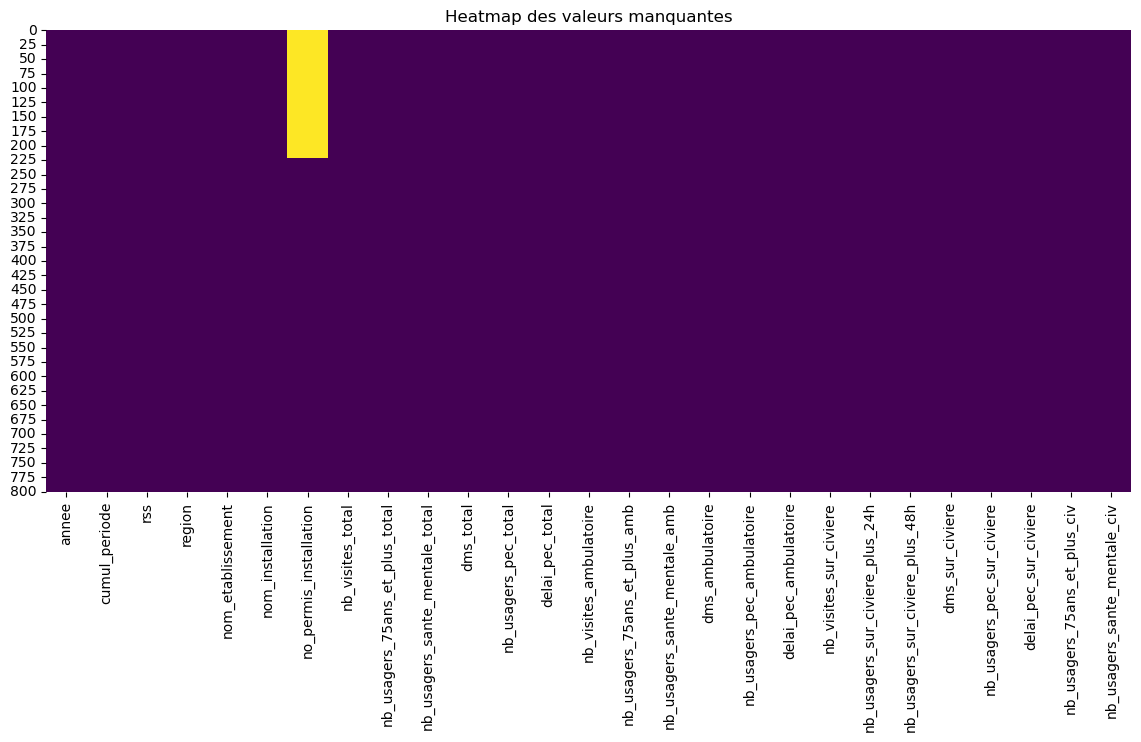


INTERPRÉTATION :

- Cette analyse permet d’identifier les colonnes contenant
  des données manquantes.

- Si plusieurs valeurs manquent :
    -> cela peut réduire la qualité du modèle.

- Solutions possibles :
    -> supprimer les lignes
    -> remplacer par moyenne/médiane/mode



In [ ]:
# =========================
# 2.1 Detecter les valeurs manquantes 
# =========================
print("\n================ VALEURS MANQUANTES =================\n")

missing_values = df.isnull().sum()

print(missing_values)

# Visualisation

plt.figure(figsize=(14,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap='viridis'
)

plt.title("Heatmap des valeurs manquantes")

plt.show()

# ============================================================
# INTERPRÉTATION
# ============================================================

print("""
INTERPRÉTATION :

- Cette analyse permet d’identifier les colonnes contenant
  des données manquantes.

- Si plusieurs valeurs manquent :
    -> cela peut réduire la qualité du modèle.

- Solutions possibles :
    -> supprimer les lignes
    -> remplacer par moyenne/médiane/mode
""")



Colonnes numériques :

Index(['cumul_periode', 'rss', 'no_permis_installation', 'nb_visites_total',
       'nb_usagers_75ans_et_plus_total', 'nb_usagers_sante_mentale_total',
       'dms_total', 'nb_usagers_pec_total', 'delai_pec_total',
       'nb_visites_ambulatoire', 'nb_usagers_75ans_et_plus_amb',
       'nb_usagers_sante_mentale_amb', 'dms_ambulatoire',
       'nb_usagers_pec_ambulatoire', 'delai_pec_ambulatoire',
       'nb_visites_sur_civiere', 'nb_usagers_sur_civiere_plus_24h',
       'nb_usagers_sur_civiere_plus_48h', 'dms_sur_civiere',
       'nb_usagers_pec_sur_civiere', 'delai_pec_sur_civiere',
       'nb_usagers_75ans_et_plus_civ', 'nb_usagers_sante_mentale_civ'],
      dtype='object')


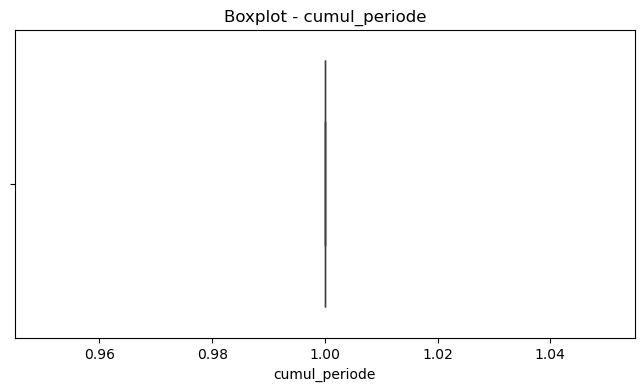

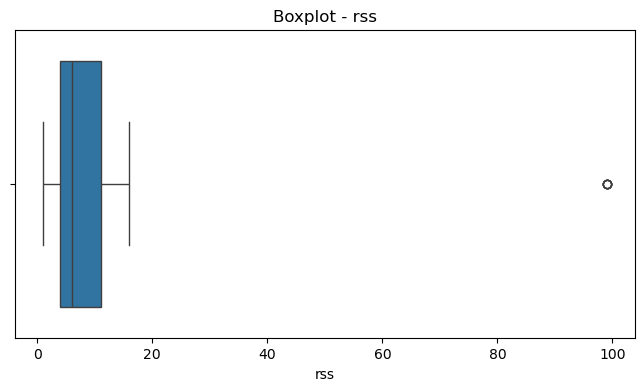

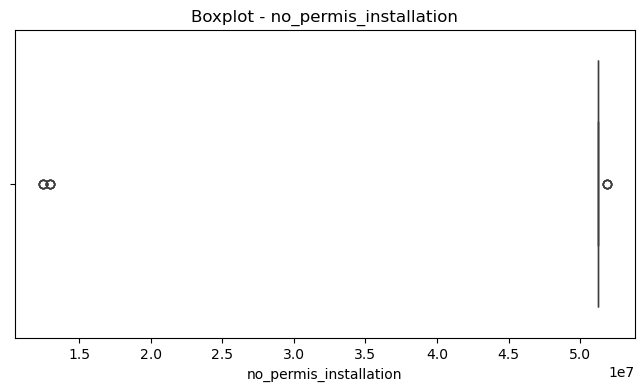

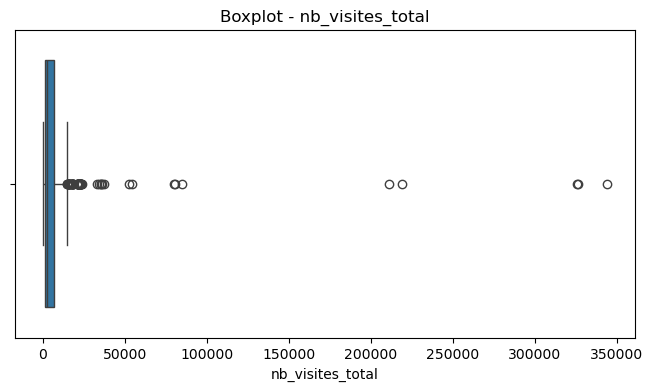

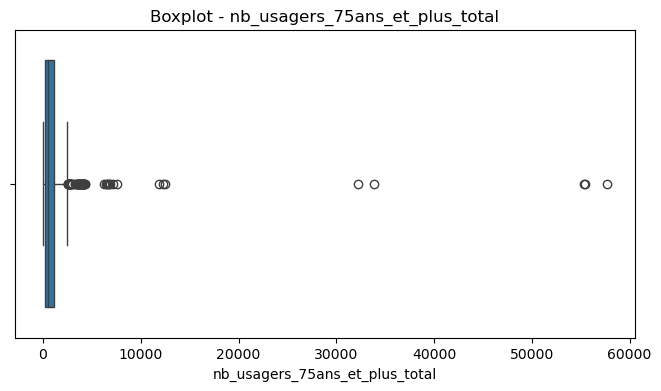

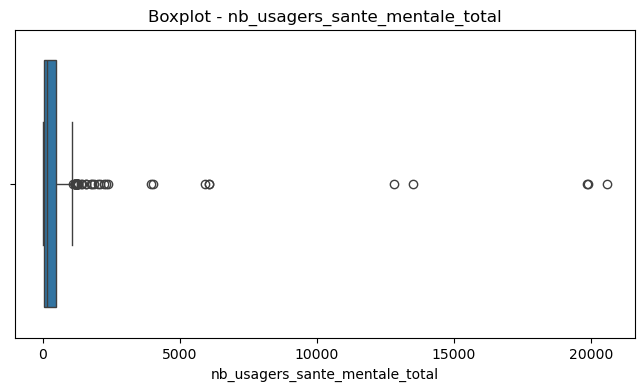

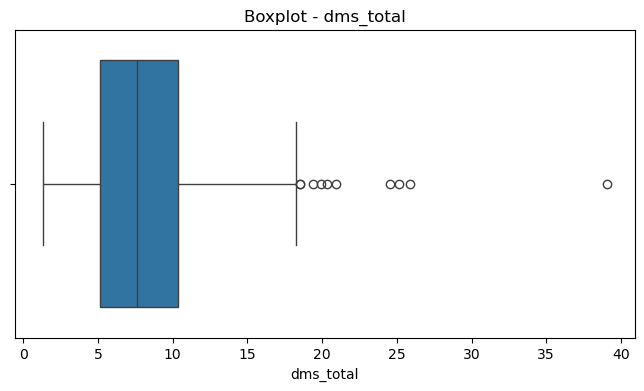

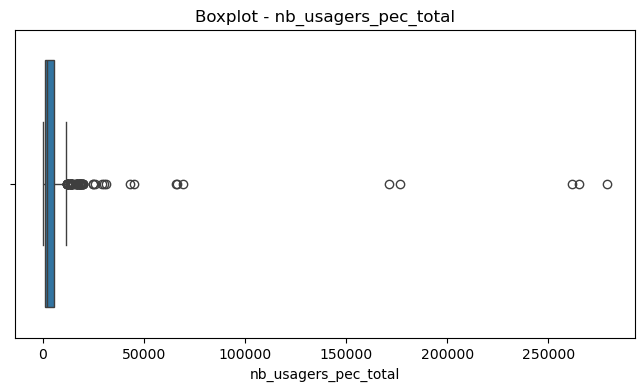

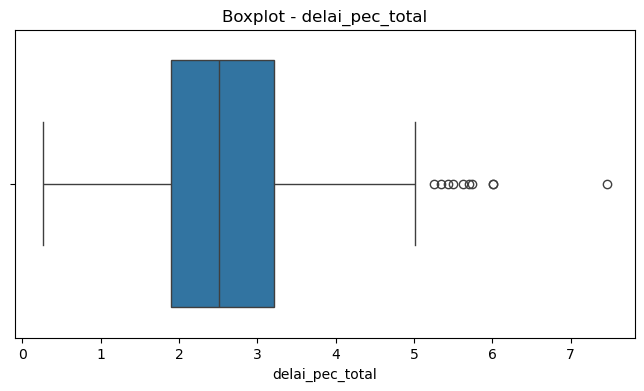

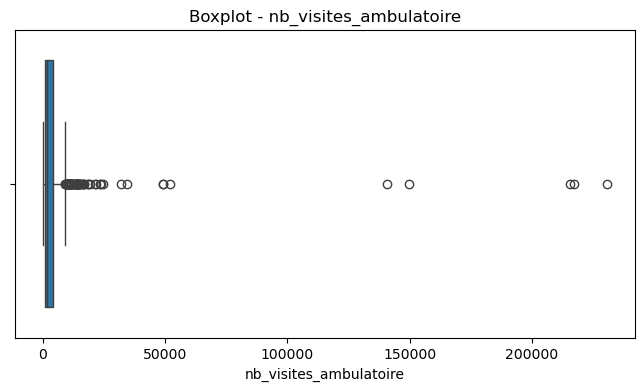

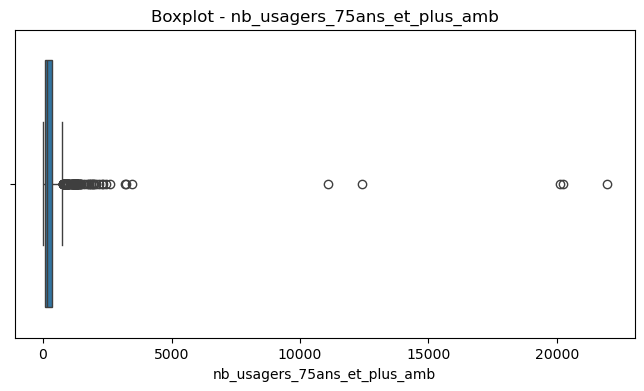

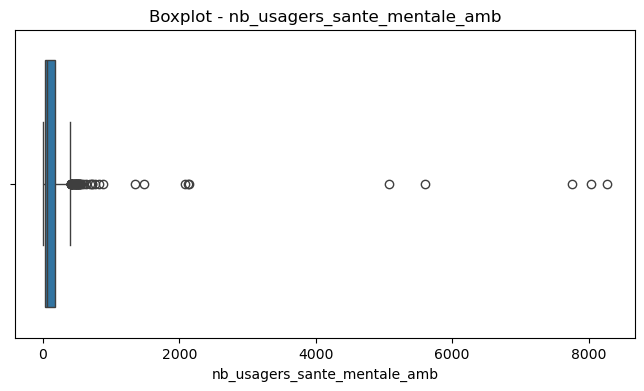

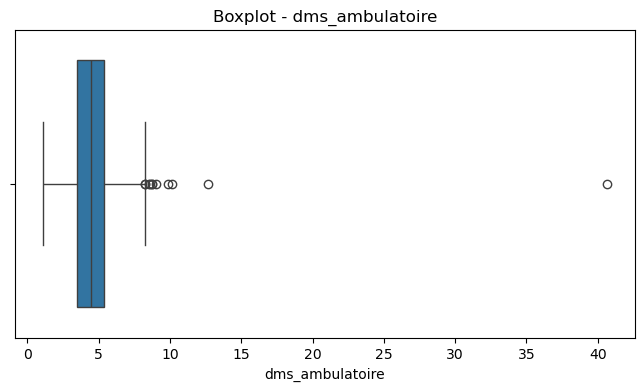

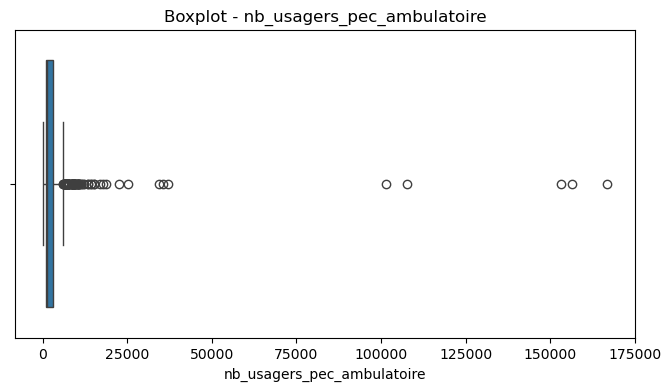

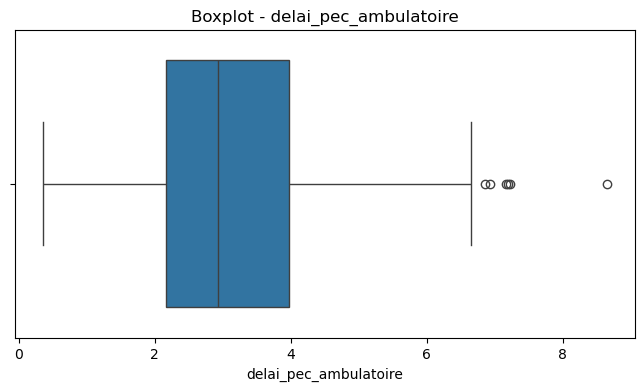

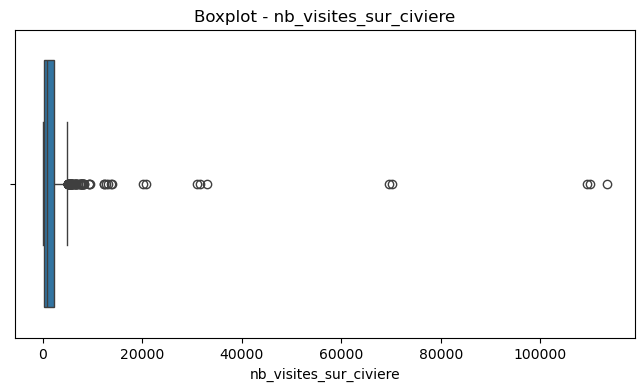

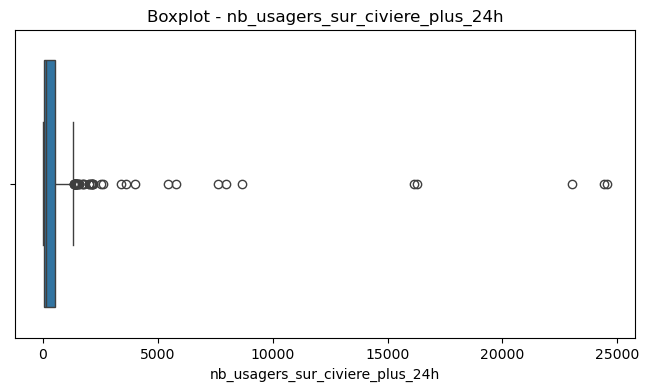

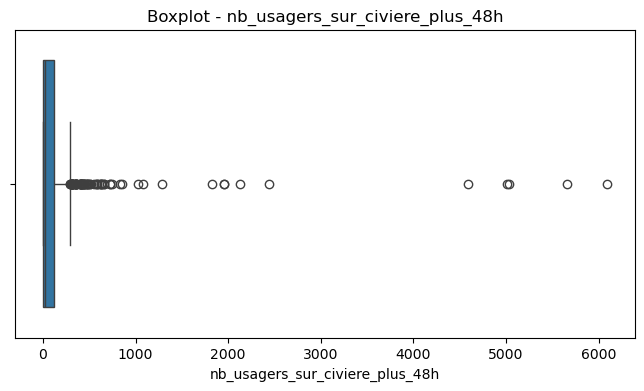

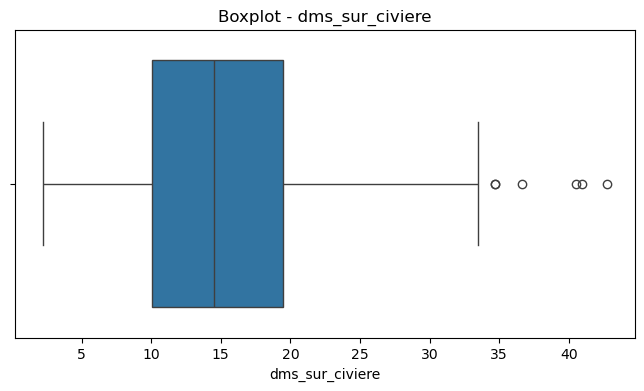

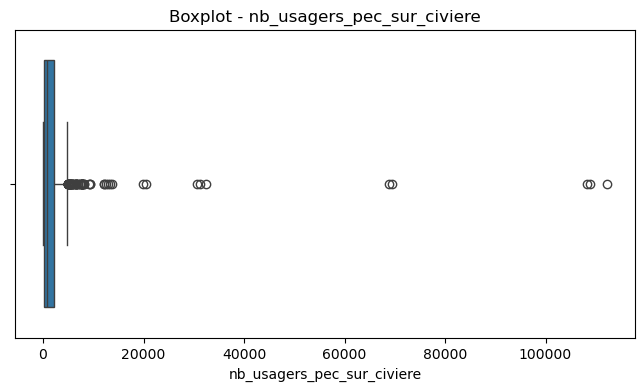

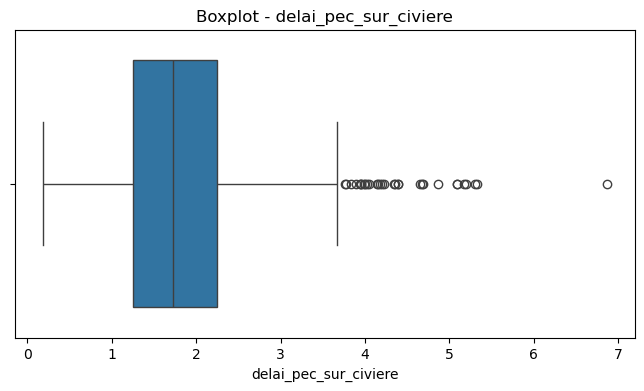

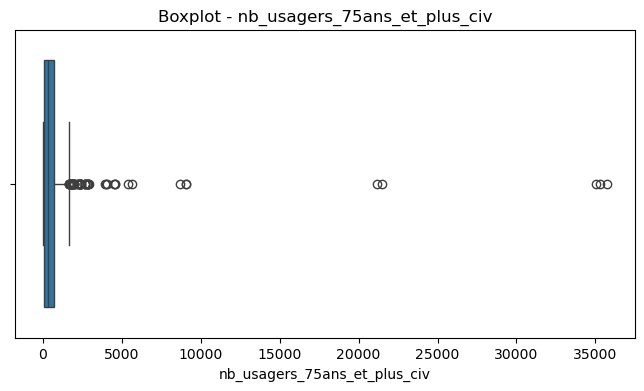

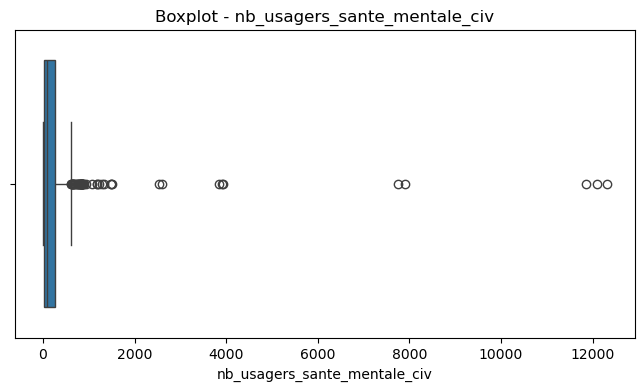

In [ ]:
# =========================
# 2.2 Detecter les valeurs abberantes - Outlaiers 
# =========================

numeric_cols = df.select_dtypes(include=np.number).columns

print("\nColonnes numériques :\n")
print(numeric_cols)

# Boxplots

for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[col])

    plt.title(f"Boxplot - {col}")

    plt.show()

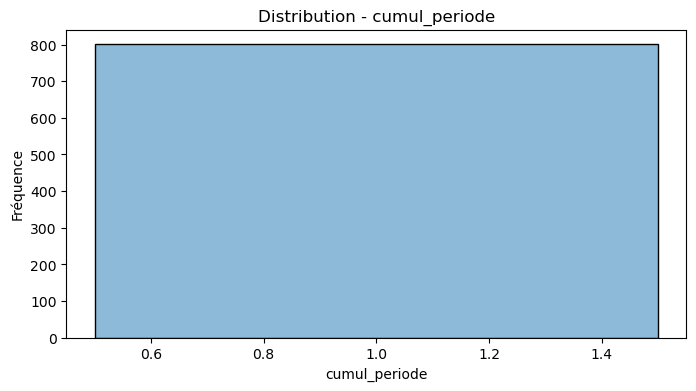

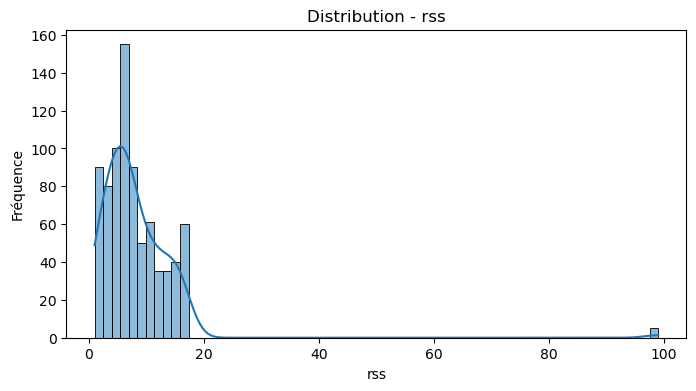

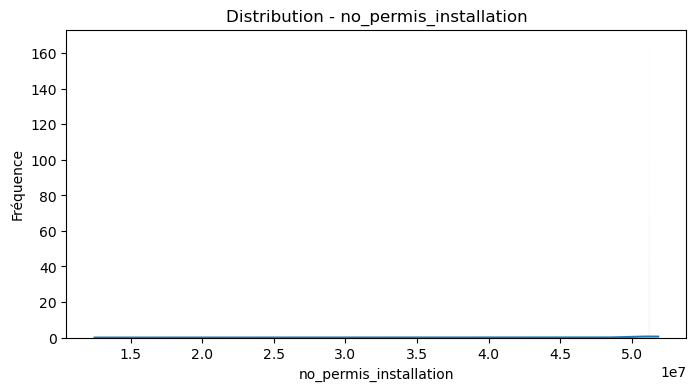

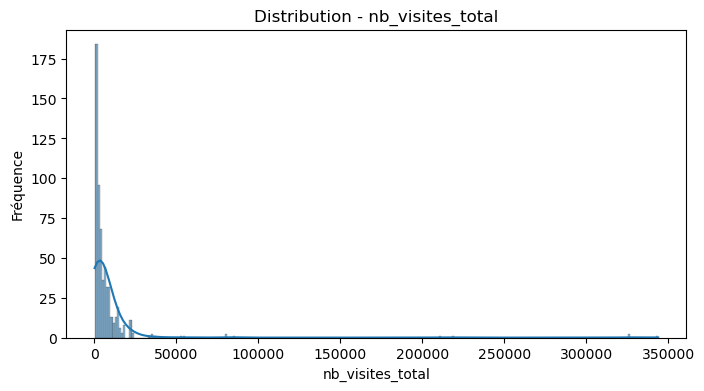

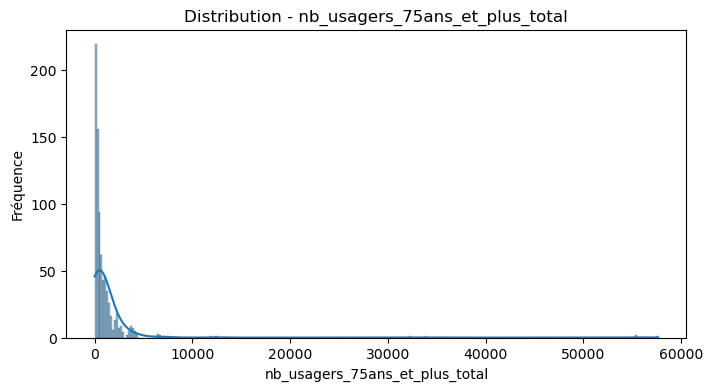

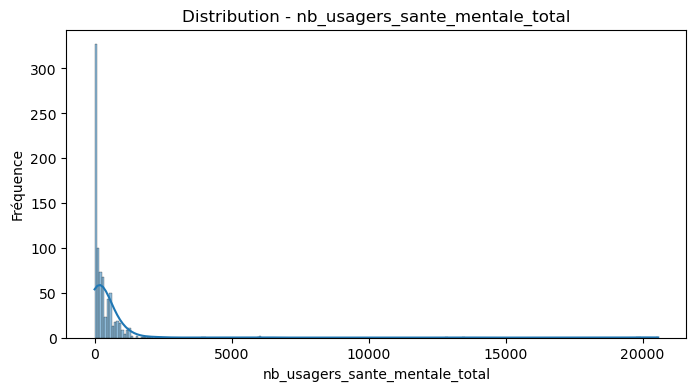

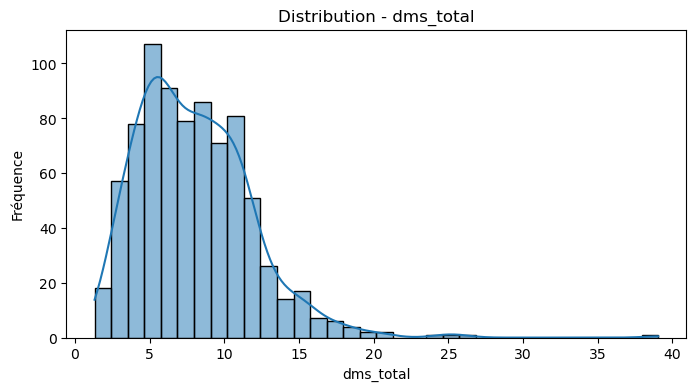

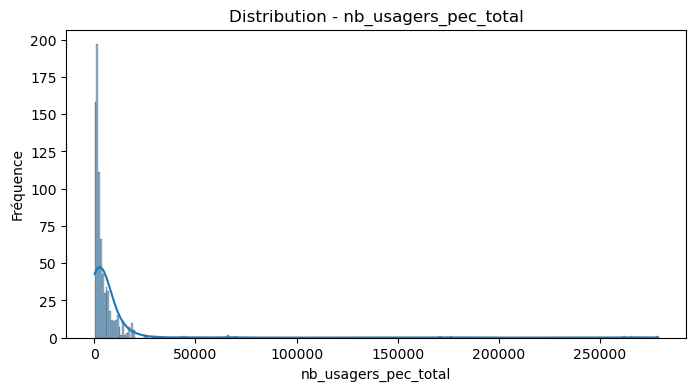

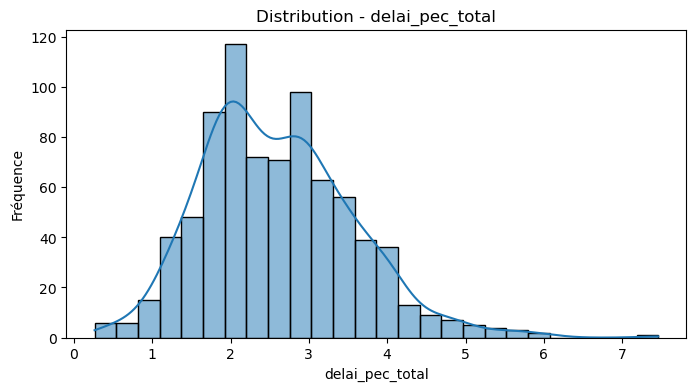

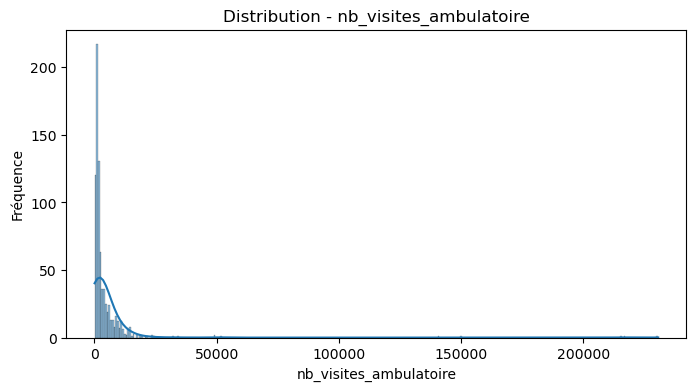

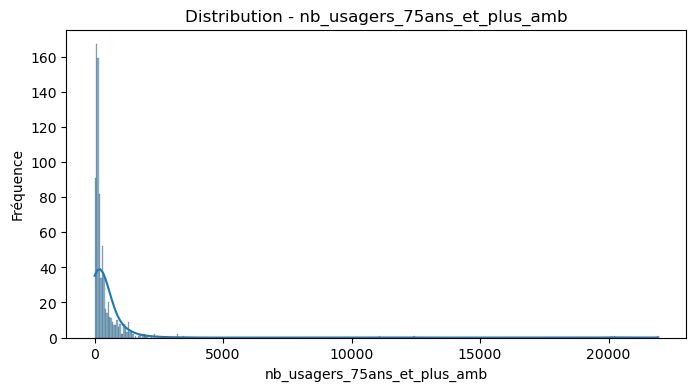

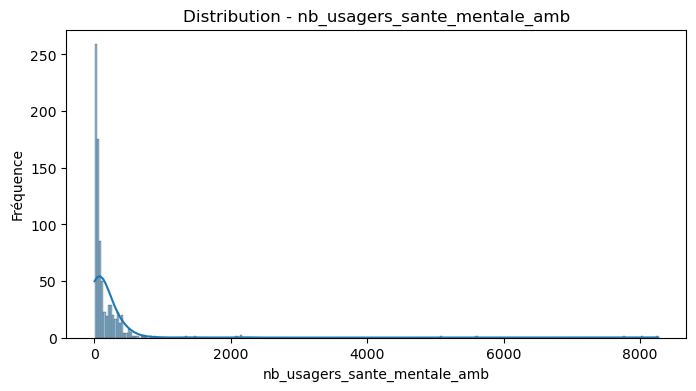

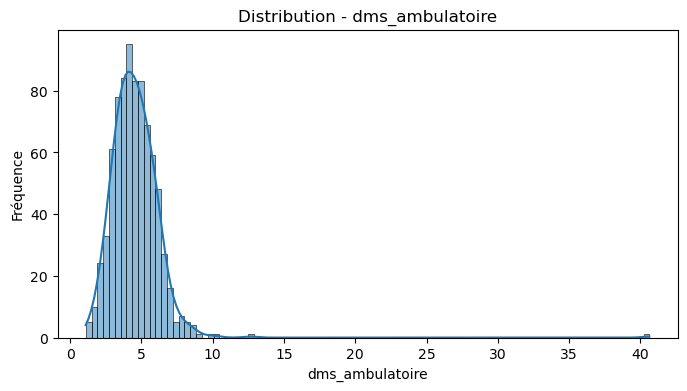

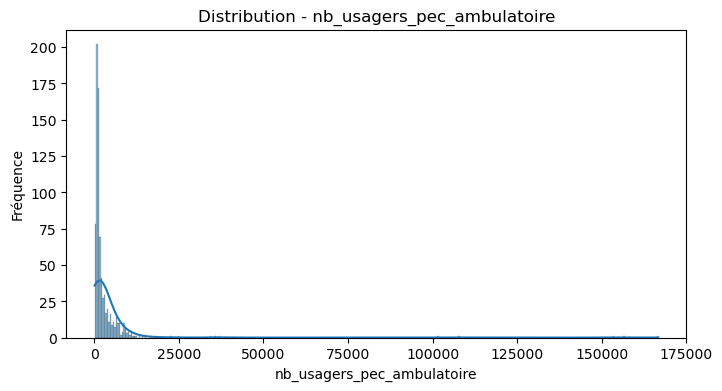

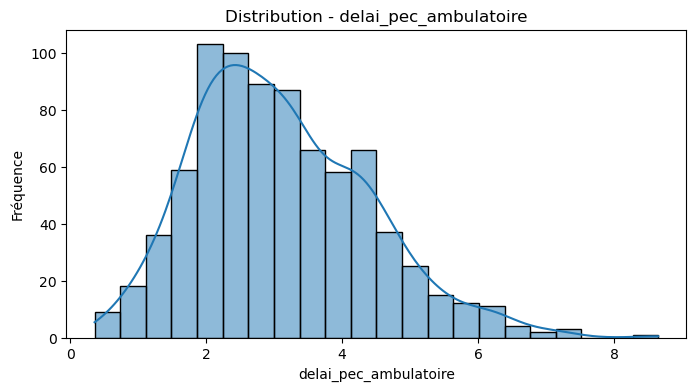

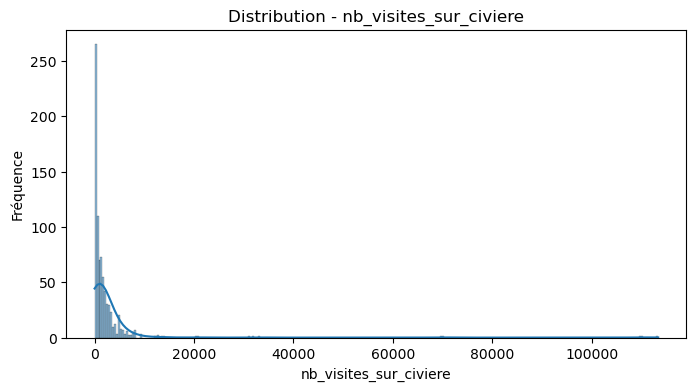

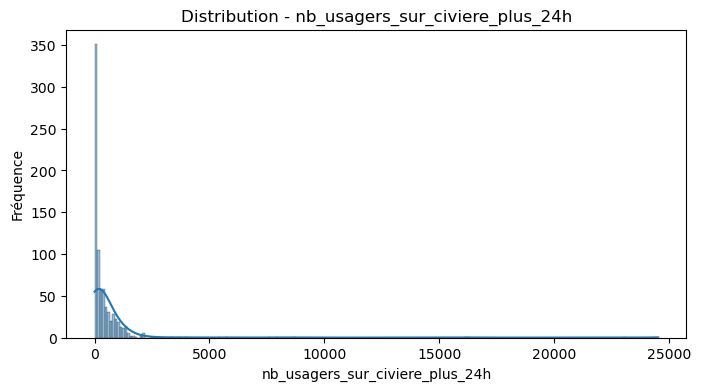

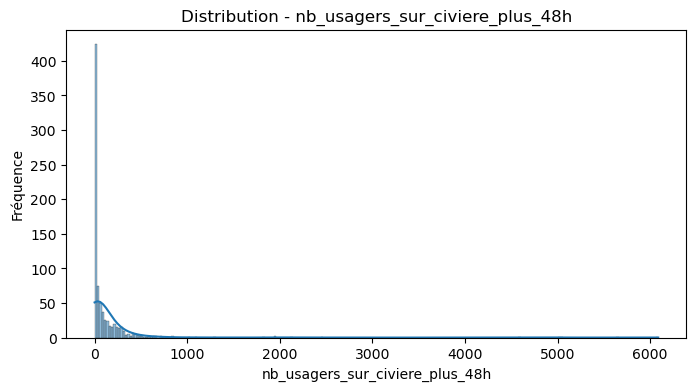

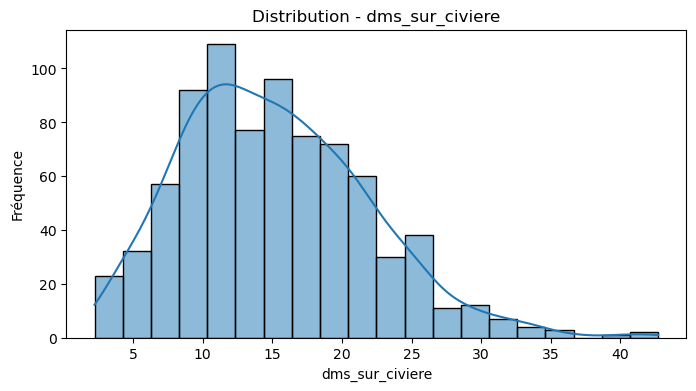

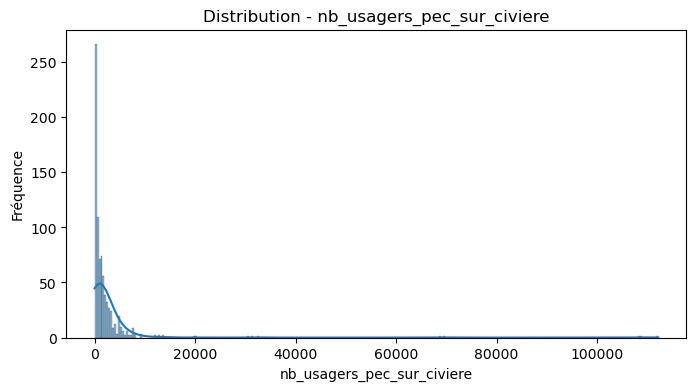

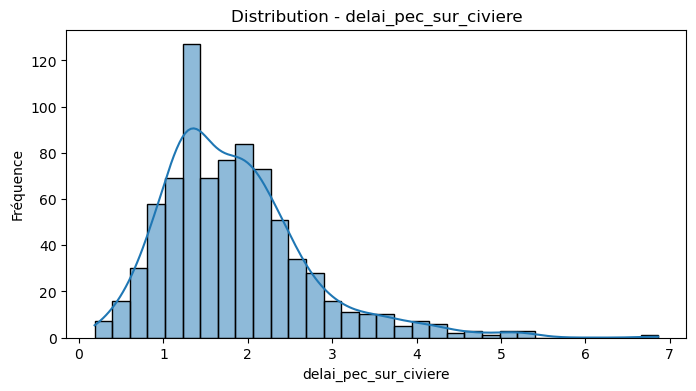

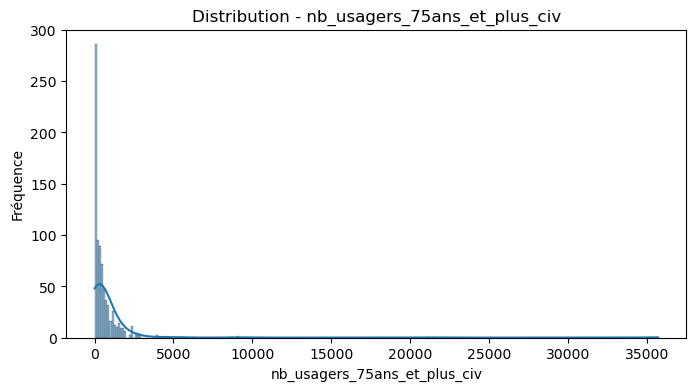

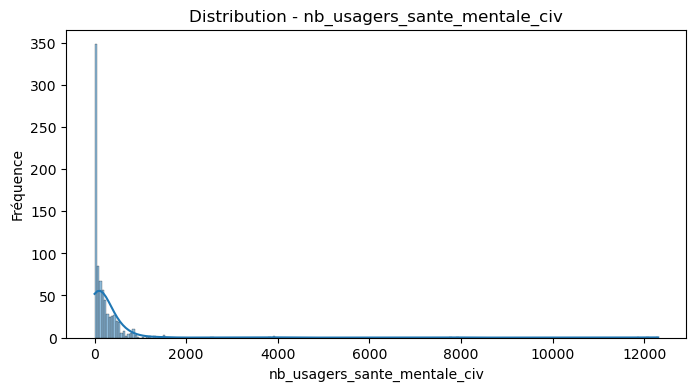


INTERPRÉTATION :

- Les points extrêmes représentent des valeurs aberrantes.

- Les outliers peuvent :
    -> biaiser les statistiques
    -> réduire les performances du modèle

- Dans Gaussian Naive Bayes :
    -> les distributions extrêmes peuvent perturber
       les probabilités.



In [ ]:
# =========================
# 2.3 Distribution de probabilitee 
# =========================
for col in numeric_cols:

    plt.figure(figsize=(8,4))

    sns.histplot(df[col], kde=True)

    plt.title(f"Distribution - {col}")

    plt.xlabel(col)

    plt.ylabel("Fréquence")

    plt.show()

    
# ============================================================
# INTERPRÉTATION
# ============================================================

print("""
INTERPRÉTATION :

- Les points extrêmes représentent des valeurs aberrantes.

- Les outliers peuvent :
    -> biaiser les statistiques
    -> réduire les performances du modèle

- Dans Gaussian Naive Bayes :
    -> les distributions extrêmes peuvent perturber
       les probabilités.
""")

In [ ]:
# =========================
# 2.4 Correlation  
# =========================

from sklearn.preprocessing import LabelEncoder

df_corr = df.copy()

le = LabelEncoder()

for col in df_corr.columns:
    if df_corr[col].dtype == "object":
        df_corr[col] = le.fit_transform(df_corr[col].astype(str))

In [ ]:
# =========================
# 2.5 Identifier les variables catégorielles 
# =========================

categorical_cols = df.select_dtypes(include='object').columns

print("\n================ VARIABLES CATÉGORIELLES =================\n")

for col in categorical_cols:

    print("\n--------------------------------")
    print("Colonne :", col)

    print(df[col].unique())


================ VARIABLES CATÉGORIELLES =================


--------------------------------
Colonne : annee
['2022-2023' '2023-2024' '2024-2025' '2025-2026' '2026-2027']

--------------------------------
Colonne : region
['Total provincial' 'Abitibi-Témiscamingue' 'Bas-Saint-Laurent'
 'Capitale-Nationale' 'Chaudière-Appalaches' 'Côte-Nord' 'Estrie'
 'Gaspésie-Îles-de-la-Madeleine' 'Lanaudière' 'Laurentides' 'Laval'
 'Mauricie et Centre-du-Québec' 'Montréal' 'Montérégie' 'Outaouais'
 'Saguenay-Lac-Saint-Jean' 'Nord-du-Québec']

--------------------------------
Colonne : nom_etablissement
['Total provincial' 'Total régional' 'CISSS DU BAS-SAINT-LAURENT'
 'CIUSSS DU SAGUENAY - LAC-SAINT-JEAN' 'CHU DE QUÉBEC - UNIVERSITÉ LAVAL'
 'CIUSSS DE LA CAPITALE-NATIONALE'
 'INSTITUT UNIVERSITAIRE DE CARDIOLOGIE ET DE PNEUMOLOGIE DE QUÉBEC - UNIVERSITÉ LAVAL'
 'CIUSSS DE LA MAURICIE-ET-DU-CENTRE-DU-QUÉBEC'
 "CIUSSS DE L'ESTRIE - CENTRE HOSPITALIER UNIVERSITAIRE DE SHERBROOKE"
 "CENTRE HOSPITALIER 

In [ ]:

# ============================================================
# 8. NETTOYAGE DES DONNÉES
# ============================================================

print("\n================ NETTOYAGE =================\n")

# Suppression des valeurs manquantes

df = df.dropna()

print("Nouvelle dimension :", df.shape)


================ NETTOYAGE =================

Nouvelle dimension : (579, 27)


In [ ]:

# ============================================================
# 9. CRÉATION DE LA VARIABLE CIBLE
# ============================================================

print("\n================ COLONNES =================\n")

print(df.columns)

# ============================================================
# IMPORTANT :
# Adapter le nom de colonne selon le dataset réel
# ============================================================

target_numeric_column = numeric_cols[-1]

print("\nColonne utilisée pour créer la cible :")
print(target_numeric_column)

# Création des classes

df["Classe_Occupation"] = pd.qcut(
    df[target_numeric_column],
    q=3,
    labels=[0,1,2]
)


================ COLONNES =================

Index(['annee', 'cumul_periode', 'rss', 'region', 'nom_etablissement',
       'nom_installation', 'no_permis_installation', 'nb_visites_total',
       'nb_usagers_75ans_et_plus_total', 'nb_usagers_sante_mentale_total',
       'dms_total', 'nb_usagers_pec_total', 'delai_pec_total',
       'nb_visites_ambulatoire', 'nb_usagers_75ans_et_plus_amb',
       'nb_usagers_sante_mentale_amb', 'dms_ambulatoire',
       'nb_usagers_pec_ambulatoire', 'delai_pec_ambulatoire',
       'nb_visites_sur_civiere', 'nb_usagers_sur_civiere_plus_24h',
       'nb_usagers_sur_civiere_plus_48h', 'dms_sur_civiere',
       'nb_usagers_pec_sur_civiere', 'delai_pec_sur_civiere',
       'nb_usagers_75ans_et_plus_civ', 'nb_usagers_sante_mentale_civ'],
      dtype='object')

Colonne utilisée pour créer la cible :
nb_usagers_sante_mentale_civ


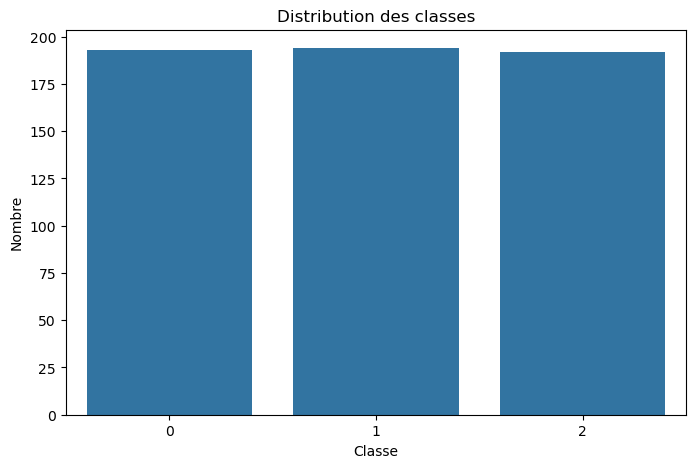


================ DISTRIBUTION DES CLASSES =================

Classe_Occupation
1    194
0    193
2    192
Name: count, dtype: int64

Pourcentage :

Classe_Occupation
1    33.506045
0    33.333333
2    33.160622
Name: proportion, dtype: float64

INTERPRÉTATION :

- Cette analyse vérifie si les classes sont équilibrées.

- Si une classe domine :
    -> le modèle peut devenir biaisé.

- Solutions possibles :
    -> SMOTE
    -> Oversampling
    -> Undersampling



In [ ]:


# ============================================================
# 10. DÉTECTION DU DÉSÉQUILIBRE DES CLASSES
# ============================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Classe_Occupation"]
)

plt.title("Distribution des classes")

plt.xlabel("Classe")

plt.ylabel("Nombre")

plt.show()

print("\n================ DISTRIBUTION DES CLASSES =================\n")

print(df["Classe_Occupation"].value_counts())

print("\nPourcentage :\n")

print(
    df["Classe_Occupation"].value_counts(normalize=True) * 100
)


# ============================================================
# INTERPRÉTATION
# ============================================================

print("""
INTERPRÉTATION :

- Cette analyse vérifie si les classes sont équilibrées.

- Si une classe domine :
    -> le modèle peut devenir biaisé.

- Solutions possibles :
    -> SMOTE
    -> Oversampling
    -> Undersampling
""")

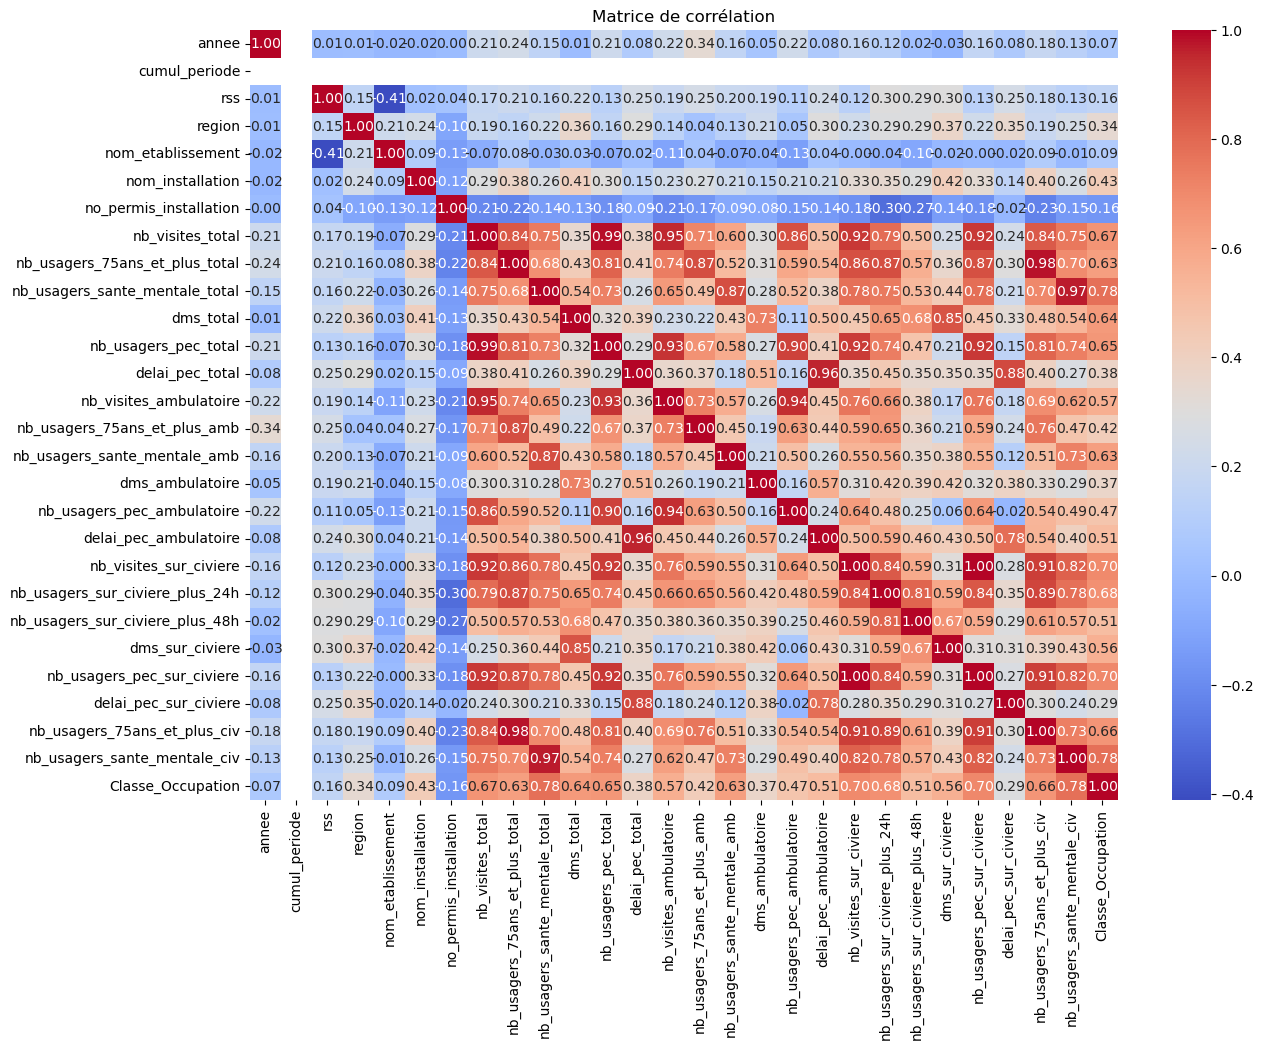


INTERPRÉTATION :

- La heatmap montre les relations entre variables.

- Naive Bayes suppose que les variables X
  sont indépendantes.

- Une forte corrélation peut :
    -> violer cette hypothèse
    -> diminuer les performances du modèle



In [ ]:

# ============================================================
# 11. MATRICE DE CORRÉLATION
# ============================================================

df_corr = df.copy()

le_temp = LabelEncoder()

for col in df_corr.columns:

    if df_corr[col].dtype == "object":

        df_corr[col] = le_temp.fit_transform(
            df_corr[col].astype(str)
        )

plt.figure(figsize=(14,10))

corr_matrix = df_corr.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()


# ============================================================
# INTERPRÉTATION
# ============================================================

print("""
INTERPRÉTATION :

- La heatmap montre les relations entre variables.

- Naive Bayes suppose que les variables X
  sont indépendantes.

- Une forte corrélation peut :
    -> violer cette hypothèse
    -> diminuer les performances du modèle
""")


# PRÉTRAITEMENT

In [ ]:
# ============================================================
# 12. SÉPARATION X ET Y
# ============================================================

X = df.drop("Classe_Occupation", axis=1)

y = df["Classe_Occupation"]

In [ ]:
# ============================================================
# 13. ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================================

le = LabelEncoder()

for col in X.columns:

    if X[col].dtype == "object":

        X[col] = le.fit_transform(
            X[col].astype(str)
        )

In [ ]:
# ============================================================
# 14. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
# ============================================================
# 15. ENTRAÎNEMENT DU MODÈLE
# ============================================================

model = GaussianNB()

model.fit(X_train, y_train)

GaussianNB()

In [ ]:
# ============================================================
# 16. PRÉDICTIONS
# ============================================================

y_pred = model.predict(X_test)


In [ ]:
# ============================================================
# 17. ÉVALUATION DU MODÈLE
# ============================================================

print("\n================ ACCURACY =================\n")

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy :", accuracy)


================ ACCURACY =================

Accuracy : 0.603448275862069



================ RAPPORT DE CLASSIFICATION =================

              precision    recall  f1-score   support

           0       0.66      0.93      0.77        42
           1       0.42      0.41      0.42        39
           2       0.79      0.43      0.56        35

    accuracy                           0.60       116
   macro avg       0.62      0.59      0.58       116
weighted avg       0.62      0.60      0.59       116



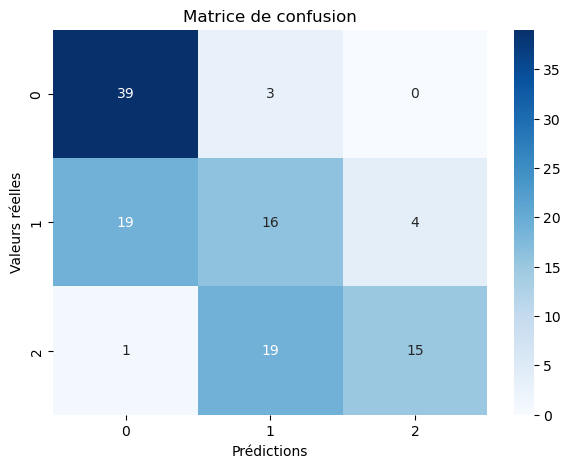

In [ ]:
# ============================================================

print("\n================ RAPPORT DE CLASSIFICATION =================\n")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# MATRICE DE CONFUSION
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Matrice de confusion")

plt.xlabel("Prédictions")

plt.ylabel("Valeurs réelles")

plt.show()

In [ ]:

# ============================================================
# 18. EXEMPLE DE PRÉDICTION
# ============================================================

nouvelle_donnee = X_test.iloc[0:1]

prediction = model.predict(nouvelle_donnee)

print("\n================ PRÉDICTION =================\n")

print("Classe prédite :", prediction)


================ PRÉDICTION =================

Classe prédite : [0]


In [ ]:

# ============================================================
# 19. THÉORÈME DE BAYES
# ============================================================

print("""
THÉORÈME DE BAYES :

P(A|B) = ( P(B|A) * P(A) ) / P(B)

Naive Bayes suppose que :
-> les variables explicatives sont indépendantes.
""")



THÉORÈME DE BAYES :

P(A|B) = ( P(B|A) * P(A) ) / P(B)

Naive Bayes suppose que :
-> les variables explicatives sont indépendantes.

